# Heart Disease Prediction
## Paper: https://www.nature.com/articles/s41598-024-74656-2#Tab5
### A proposed technique for predicting heart disease using machine learning algorithms and an explainable AI method

## Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from imblearn.over_sampling import SMOTE

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (
    VotingClassifier, AdaBoostClassifier, 
    BaggingClassifier, RandomForestClassifier
)
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import shap
import pickle

In [ ]:
train_df = pd.read_csv("data/train.csv", encoding='utf-8')
print(f"Training data shape: {train_df.shape}")
train_df.head()

Training data shape: (630000, 15)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [ ]:
mapping = {'Presence': 1, 'Absence': 0}
train_df['Heart_Disease'] = train_df['Heart Disease'].map(mapping)

print("\nTarget distribution:")
print(train_df['Heart_Disease'].value_counts())
print(f"\nClass balance: {train_df['Heart_Disease'].value_counts(normalize=True)}")

train_df.head()


Target distribution:
Heart_Disease
0    347546
1    282454
Name: count, dtype: int64

Class balance: Heart_Disease
0    0.55166
1    0.44834
Name: proportion, dtype: float64


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,Heart_Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence,1


## Data Exploration and Preprocessing

In [6]:
# Check dataset info
print("Dataset shape:", train_df.shape)
print("\nColumn names:")
print(train_df.columns.tolist())
print("\nData types:")
print(train_df.dtypes)
print("\nMissing values:")
print(train_df.isnull().sum())
print("\nBasic statistics:")
print(train_df.describe())

Dataset shape: (630000, 16)

Column names:
['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease', 'Heart_Disease']

Data types:
id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
Heart_Disease                int64
dtype: object

Missing values:
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP         

In [ ]:
# Handle missing values 
if 'Heart Disease' in train_df.columns:
    train_df = train_df.drop('Heart Disease', axis=1)

# Separate features and target
X = train_df.drop('Heart_Disease', axis=1)
y = train_df['Heart_Disease']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (630000, 14)
Target shape: (630000,)

Feature columns:
['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


In [ ]:
# Standardizing features using StandardScaler (as per paper)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Data normalized using StandardScaler")
print("Scaled data shape:", X_scaled.shape)
print("\nScaled data statistics (should have mean≈0, std≈1):")
print(X_scaled.describe())

Data normalized using StandardScaler
Scaled data shape: (630000, 14)

Scaled data statistics (should have mean≈0, std≈1):
                 id           Age           Sex  Chest pain type  \
count  6.300000e+05  6.300000e+05  6.300000e+05     6.300000e+05   
mean   9.239311e-17 -2.941421e-17  2.233134e-17     8.228762e-17   
std    1.000001e+00  1.000001e+00  1.000001e+00     1.000001e+00   
min   -1.732048e+00 -3.044551e+00 -1.582881e+00    -2.715729e+00   
25%   -8.660240e-01 -7.432761e-01 -1.582881e+00    -3.672467e-01   
50%    0.000000e+00 -1.655783e-02  6.317595e-01     8.069943e-01   
75%    8.660240e-01  7.101604e-01  6.317595e-01     8.069943e-01   
max    1.732048e+00  2.769196e+00  6.317595e-01     8.069943e-01   

                 BP   Cholesterol  FBS over 120   EKG results        Max HR  \
count  6.300000e+05  6.300000e+05  6.300000e+05  6.300000e+05  6.300000e+05   
mean  -5.052748e-18  1.742296e-16 -3.067740e-17  5.197113e-17 -4.603415e-16   
std    1.000001e+00  1.00000

## Feature Selection
### Three Methods: ANOVA F-value, Chi-square, and Mutual Information

In [ ]:
# ANOVA F-value (FSM1)
f_selector = SelectKBest(score_func=f_classif, k='all')
f_selector.fit(X_scaled, y)
f_scores = pd.DataFrame({
    'Feature': X.columns,
    'ANOVA_F_Score': f_selector.scores_
}).sort_values(by='ANOVA_F_Score', ascending=False)

# Chi-square (FSM2) - need positive values for chi2
X_scaled_positive = X_scaled - X_scaled.min() + 0.01
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_scaled_positive, y)
chi_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi_Square_Score': chi_selector.scores_
}).sort_values(by='Chi_Square_Score', ascending=False)

# Mutual Information (FSM3)
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_scaled, y)
mi_scores = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_selector.scores_
}).sort_values(by='MI_Score', ascending=False)

print("=" * 80)
print("FEATURE SELECTION RESULTS")
print("=" * 80)
print("\nMethod 1: ANOVA F-value Scores (FSM1):")
print(f_scores.to_string(index=False))
print("\n" + "=" * 80)
print("\nMethod 2: Chi-square Scores (FSM2):")
print(chi_scores.to_string(index=False))
print("\n" + "=" * 80)
print("\nMethod 3: Mutual Information Scores (FSM3):")
print(mi_scores.to_string(index=False))

FEATURE SELECTION RESULTS

Method 1: ANOVA F-value Scores (FSM1):
                Feature  ANOVA_F_Score
               Thallium  365204.522813
        Chest pain type  169724.640674
        Exercise angina  152845.064648
                 Max HR  152091.489484
Number of vessels fluro  150062.663039
          ST depression  143433.980883
            Slope of ST  131114.304073
                    Sex   83694.296164
            EKG results   31725.725389
                    Age   29673.836821
            Cholesterol    4343.993902
           FBS over 120     710.785779
                     BP      16.911513
                     id       0.027439


Method 2: Chi-square Scores (FSM2):
                Feature  Chi_Square_Score
               Thallium     275161.938926
Number of vessels fluro     210838.253894
        Exercise angina     197148.257366
          ST depression     152738.931192
            Slope of ST     128258.281800
        Chest pain type      49052.757344
                 

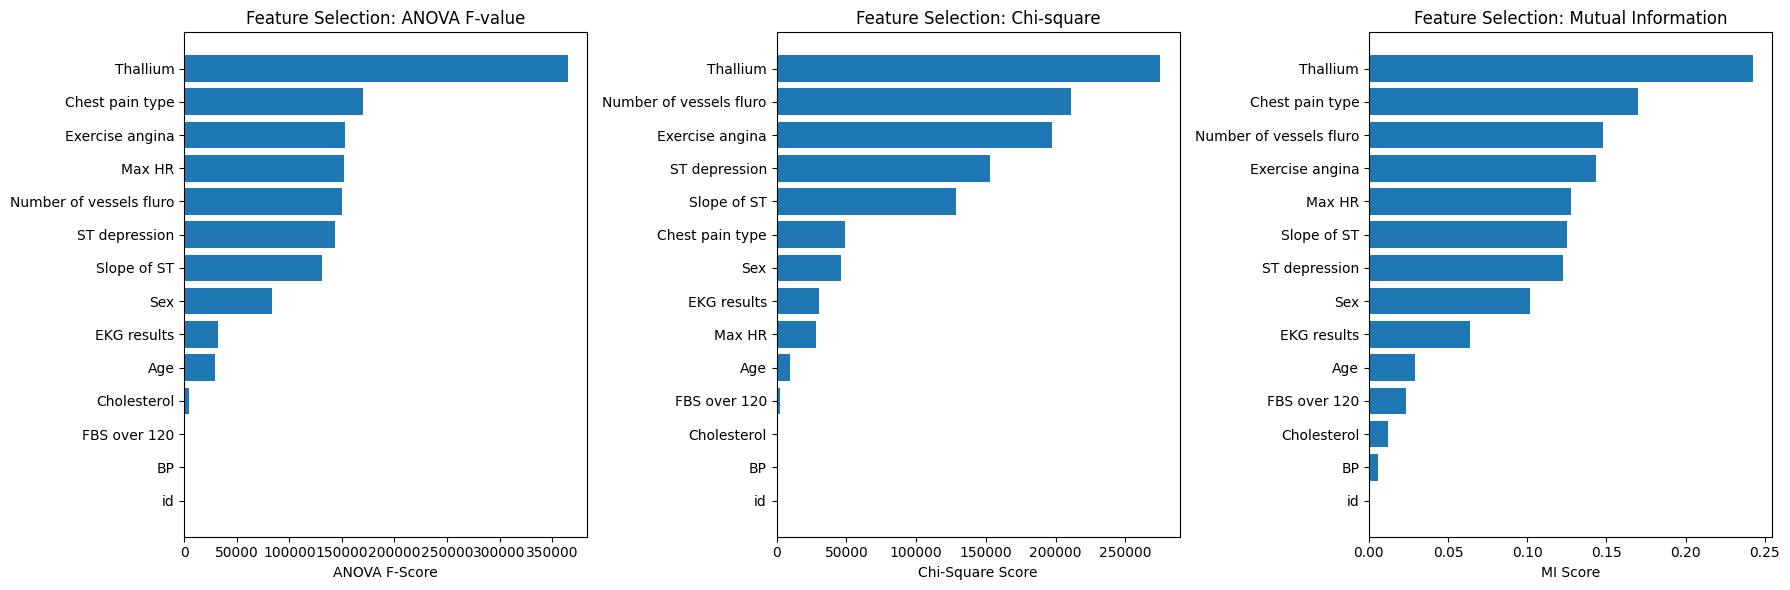

In [ ]:
# Visualise Visualise Visualise!
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ANOVA F-value
axes[0].barh(f_scores['Feature'], f_scores['ANOVA_F_Score'])
axes[0].set_xlabel('ANOVA F-Score')
axes[0].set_title('Feature Selection: ANOVA F-value')
axes[0].invert_yaxis()

# Chi-square
axes[1].barh(chi_scores['Feature'], chi_scores['Chi_Square_Score'])
axes[1].set_xlabel('Chi-Square Score')
axes[1].set_title('Feature Selection: Chi-square')
axes[1].invert_yaxis()

# Mutual Information
axes[2].barh(mi_scores['Feature'], mi_scores['MI_Score'])
axes[2].set_xlabel('MI Score')
axes[2].set_title('Feature Selection: Mutual Information')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Create Feature Subsets (SF-1, SF-2, SF-3)

In [ ]:
# Combining rankings from all three methods
feature_importance = pd.DataFrame({'Feature': X.columns})

# adding rankings
for feat in X.columns:
    feature_importance.loc[feature_importance['Feature'] == feat, 'ANOVA_Rank'] = \
        f_scores[f_scores['Feature'] == feat].index[0] + 1
    feature_importance.loc[feature_importance['Feature'] == feat, 'Chi_Rank'] = \
        chi_scores[chi_scores['Feature'] == feat].index[0] + 1
    feature_importance.loc[feature_importance['Feature'] == feat, 'MI_Rank'] = \
        mi_scores[mi_scores['Feature'] == feat].index[0] + 1

# average rank
feature_importance['Avg_Rank'] = feature_importance[['ANOVA_Rank', 'Chi_Rank', 'MI_Rank']].mean(axis=1)
feature_importance = feature_importance.sort_values('Avg_Rank')

print("Combined Feature Ranking (Lower rank = more important):")
print(feature_importance.to_string(index=False))

# defining feature subsets based on research paper methodology
SF_1 = X.columns.tolist()  # All features
SF_2 = feature_importance.head(10)['Feature'].tolist()  # Top 10 features
SF_3 = feature_importance.head(9)['Feature'].tolist()  # Top 9 features

print("\n" + "=" * 80)
print("FEATURE SUBSETS")
print("=" * 80)
print(f"\nSF-1 (All features): {len(SF_1)} features")
print(SF_1)
print(f"\nSF-2 (Top 10 features): {len(SF_2)} features")
print(SF_2)
print(f"\nSF-3 (Top 9 features): {len(SF_3)} features")
print(SF_3)

Combined Feature Ranking (Lower rank = more important):
                Feature  ANOVA_Rank  Chi_Rank  MI_Rank  Avg_Rank
                     id         1.0       1.0      1.0       1.0
                    Age         2.0       2.0      2.0       2.0
                    Sex         3.0       3.0      3.0       3.0
        Chest pain type         4.0       4.0      4.0       4.0
                     BP         5.0       5.0      5.0       5.0
            Cholesterol         6.0       6.0      6.0       6.0
           FBS over 120         7.0       7.0      7.0       7.0
            EKG results         8.0       8.0      8.0       8.0
                 Max HR         9.0       9.0      9.0       9.0
        Exercise angina        10.0      10.0     10.0      10.0
          ST depression        11.0      11.0     11.0      11.0
            Slope of ST        12.0      12.0     12.0      12.0
Number of vessels fluro        13.0      13.0     13.0      13.0
               Thallium        14.

## Train-Test Split and SMOTE

In [ ]:
# Split data into train and test sets (75-25 split as paper)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 472500 samples
Test set size: 157500 samples

Training set class distribution:
Heart_Disease
0    260659
1    211841
Name: count, dtype: int64

Test set class distribution:
Heart_Disease
0    86887
1    70613
Name: count, dtype: int64


Before SMOTE:
Training set size: 472500
Class distribution:
Heart_Disease
0    260659
1    211841
Name: count, dtype: int64

After SMOTE:
Training set size: 521318
Class distribution:
Heart_Disease
0    260659
1    260659
Name: count, dtype: int64


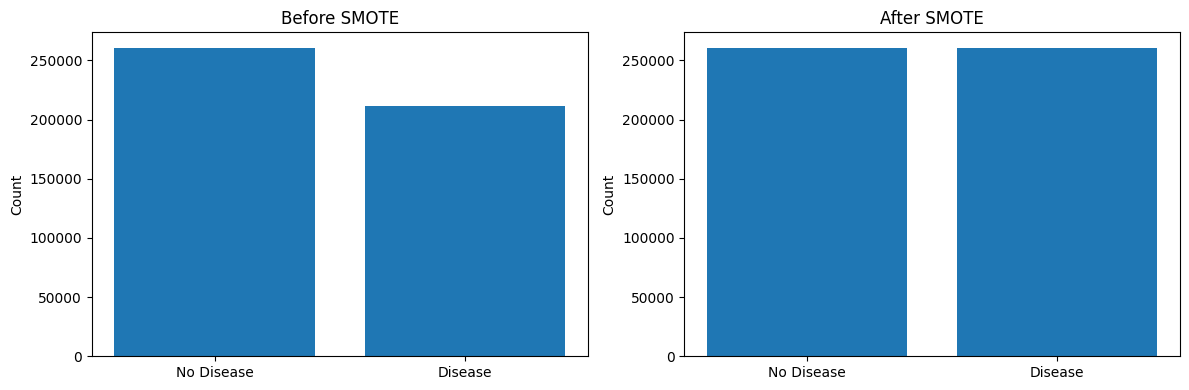

In [ ]:
# Applying SMOTE to balance the training data (paper)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"Training set size: {X_train.shape[0]}")
print(f"Class distribution:\n{y_train.value_counts()}\n")

print("After SMOTE:")
print(f"Training set size: {X_train_smote.shape[0]}")
print(f"Class distribution:\n{pd.Series(y_train_smote).value_counts()}")

# visualize the effects of SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['No Disease', 'Disease'], y_train.value_counts().sort_index())
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
axes[1].bar(['No Disease', 'Disease'], pd.Series(y_train_smote).value_counts().sort_index())
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('smote_effect.png', dpi=300, bbox_inches='tight')
plt.show()

## Model Training
### Training ML Classifiers as per the paper

In [ ]:
classifiers = {
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

print("8 ML Classifiers initialized:")
for i, name in enumerate(classifiers.keys(), 1):
    print(f"  {i}. {name}")

8 ML Classifiers initialized:
  1. Naive Bayes
  2. XGBoost
  3. AdaBoost
  4. Bagging
  5. Decision Tree
  6. KNN
  7. Random Forest
  8. Logistic Regression


In [ ]:
# evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model, returning performance metrics"""
    # training the model
    model.fit(X_train, y_train)
    
    # making predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    # metrics calculation like accuracy, precision, recall, f1-score, specificity, and AUC
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)  # Sensitivity
    f1 = f1_score(y_test, y_pred)
    
    # calculation of specifivity
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # AUC score
    try:
        auc = roc_auc_score(y_test, y_pred_proba)
    except:
        auc = 0
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy * 100,
        'Precision': precision * 100,
        'Sensitivity': recall * 100,
        'Specificity': specificity * 100,
        'F1 Score': f1 * 100,
        'AUC': auc * 100
    }
    
    return results, model

print("Model evaluation function defined.")

Model evaluation function defined.


### Training with SF-1 (All Features)

In [ ]:
# Train and evaluate all models with SF-1 (all features)
print("=" * 80)
print("TRAINING MODELS WITH SF-1 (ALL FEATURES)")
print("=" * 80)

results_sf1 = []
trained_models_sf1 = {}

for name, classifier in classifiers.items():
    print(f"\nTraining {name}...", end=' ')
    result, trained_model = evaluate_model(
        classifier, X_train_smote, X_test, y_train_smote, y_test, name
    )
    results_sf1.append(result)
    trained_models_sf1[name] = trained_model
    print(f"✓ Accuracy: {result['Accuracy']:.2f}%")

results_df_sf1 = pd.DataFrame(results_sf1).sort_values('Accuracy', ascending=False)
print("\n" + "=" * 80)
print("SF-1 RESULTS SUMMARY:")
print("=" * 80)
print(results_df_sf1.to_string(index=False))

# saving results
results_df_sf1.to_csv('results_SF1.csv', index=False)
print("\nResults saved to 'results_SF1.csv'")

TRAINING MODELS WITH SF-1 (ALL FEATURES)

Training Naive Bayes... ✓ Accuracy: 87.16%

Training XGBoost... ✓ Accuracy: 88.84%

Training AdaBoost... ✓ Accuracy: 88.50%

Training Bagging... ✓ Accuracy: 86.99%

Training Decision Tree... ✓ Accuracy: 82.46%

Training KNN... ✓ Accuracy: 86.65%

Training Random Forest... ✓ Accuracy: 88.25%

Training Logistic Regression... ✓ Accuracy: 88.31%

SF-1 RESULTS SUMMARY:
              Model  Accuracy  Precision  Sensitivity  Specificity  F1 Score       AUC
            XGBoost 88.836190  87.881818    87.111438    90.237895 87.494933 95.487590
           AdaBoost 88.497143  86.933641    87.493804    89.312555 87.212823 95.268496
Logistic Regression 88.311746  86.616913    87.439990    89.020222 87.026505 95.101163
      Random Forest 88.254603  86.905841    86.894764    89.359743 86.900302 94.861759
        Naive Bayes 87.158730  85.161614    86.414683    87.763417 85.783573 93.879915
            Bagging 86.988571  86.749179    83.774942    89.600285 85

### Training with SF-2 (Top 10 Features)

In [ ]:
# Train and evaluate all models with SF-2 (top 10 features)
print("=" * 80)
print("TRAINING MODELS WITH SF-2 (TOP 10 FEATURES)")
print("=" * 80)

# Selection of SF-2 features
X_train_sf2 = pd.DataFrame(X_train_smote, columns=X.columns)[SF_2]
X_test_sf2 = X_test[SF_2]

results_sf2 = []
trained_models_sf2 = {}

for name in classifiers.keys():
    print(f"\nTraining {name}...", end=' ')
    # Creating classifier instances depending on name
    if name == 'Naive Bayes':
        clf = GaussianNB()
    elif name == 'SVM':
        clf = SVC(kernel='rbf', probability=True, random_state=42)
    elif name == 'XGBoost':
        clf = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
    elif name == 'AdaBoost':
        clf = AdaBoostClassifier(random_state=42)
    elif name == 'Bagging':
        clf = BaggingClassifier(random_state=42)
    elif name == 'Decision Tree':
        clf = DecisionTreeClassifier(random_state=42)
    elif name == 'KNN':
        clf = KNeighborsClassifier()
    elif name == 'Random Forest':
        clf = RandomForestClassifier(random_state=42)
    elif name == 'Logistic Regression':
        clf = LogisticRegression(random_state=42, max_iter=1000)
    
    result, trained_model = evaluate_model(
        clf, X_train_sf2, X_test_sf2, y_train_smote, y_test, name
    )
    results_sf2.append(result)
    trained_models_sf2[name] = trained_model
    print(f"✓ Accuracy: {result['Accuracy']:.2f}%")

results_df_sf2 = pd.DataFrame(results_sf2).sort_values('Accuracy', ascending=False)
print("\n" + "=" * 80)
print("SF-2 RESULTS SUMMARY:")
print("=" * 80)
print(results_df_sf2.to_string(index=False))

# Saving results
results_df_sf2.to_csv('results_SF2.csv', index=False)
print("\nResults saved to 'results_SF2.csv'")

TRAINING MODELS WITH SF-2 (TOP 10 FEATURES)

Training Naive Bayes... ✓ Accuracy: 81.53%

Training XGBoost... ✓ Accuracy: 83.65%

Training AdaBoost... ✓ Accuracy: 83.05%

Training Bagging... ✓ Accuracy: 81.11%

Training Decision Tree... ✓ Accuracy: 75.71%

Training KNN... ✓ Accuracy: 80.35%

Training Random Forest... ✓ Accuracy: 82.58%

Training Logistic Regression... ✓ Accuracy: 82.54%

SF-2 RESULTS SUMMARY:
              Model  Accuracy  Precision  Sensitivity  Specificity  F1 Score       AUC
            XGBoost 83.649524  82.003795    81.392945    85.483444 81.697228 91.491470
           AdaBoost 83.045079  79.913616    83.059777    83.033135 81.456328 90.982273
      Random Forest 82.580317  80.702553    80.361973    84.383164 80.531903 90.231210
Logistic Regression 82.540317  79.398849    82.449407    82.614200 80.895379 90.446416
        Naive Bayes 81.531429  78.476499    81.030405    81.938610 79.733006 88.866253
            Bagging 81.112381  80.707555    76.051152    85.225638

### Training with SF-3 (Top 9 Features)

In [ ]:
# Train and evaluate all models with SF-3 (top 9 features)
print("=" * 80)
print("TRAINING MODELS WITH SF-3 (TOP 9 FEATURES)")
print("=" * 80)

# Select SF-3 features
X_train_sf3 = pd.DataFrame(X_train_smote, columns=X.columns)[SF_3]
X_test_sf3 = X_test[SF_3]

results_sf3 = []
trained_models_sf3 = {}

for name in classifiers.keys():
    print(f"\nTraining {name}...", end=' ')
    # creating classifier instances 
    if name == 'Naive Bayes':
        clf = GaussianNB()
    elif name == 'SVM':
        clf = SVC(kernel='rbf', probability=True, random_state=42)
    elif name == 'XGBoost':
        clf = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
    elif name == 'AdaBoost':
        clf = AdaBoostClassifier(random_state=42)
    elif name == 'Bagging':
        clf = BaggingClassifier(random_state=42)
    elif name == 'Decision Tree':
        clf = DecisionTreeClassifier(random_state=42)
    elif name == 'KNN':
        clf = KNeighborsClassifier()
    elif name == 'Random Forest':
        clf = RandomForestClassifier(random_state=42)
    elif name == 'Logistic Regression':
        clf = LogisticRegression(random_state=42, max_iter=1000)
    
    result, trained_model = evaluate_model(
        clf, X_train_sf3, X_test_sf3, y_train_smote, y_test, name
    )
    results_sf3.append(result)
    trained_models_sf3[name] = trained_model
    print(f"✓ Accuracy: {result['Accuracy']:.2f}%")

results_df_sf3 = pd.DataFrame(results_sf3).sort_values('Accuracy', ascending=False)
print("\n" + "=" * 80)
print("SF-3 RESULTS SUMMARY:")
print("=" * 80)
print(results_df_sf3.to_string(index=False))

# Saving results
results_df_sf3.to_csv('results_SF3.csv', index=False)
print("\nResults saved to 'results_SF3.csv'")

TRAINING MODELS WITH SF-3 (TOP 9 FEATURES)

Training Naive Bayes... ✓ Accuracy: 78.56%

Training XGBoost... ✓ Accuracy: 81.90%

Training AdaBoost... ✓ Accuracy: 81.12%

Training Bagging... ✓ Accuracy: 78.92%

Training Decision Tree... ✓ Accuracy: 73.14%

Training KNN... ✓ Accuracy: 78.42%

Training Random Forest... ✓ Accuracy: 80.61%

Training Logistic Regression... ✓ Accuracy: 80.52%

SF-3 RESULTS SUMMARY:
              Model  Accuracy  Precision  Sensitivity  Specificity  F1 Score       AUC
            XGBoost 81.896508  79.213390    80.832141    82.761518 80.014579 89.800062
           AdaBoost 81.120635  77.312452    81.933922    80.459678 79.556127 89.144919
      Random Forest 80.609524  78.026605    78.996785    81.920195 78.508698 88.288403
Logistic Regression 80.523810  76.229444    82.187416    79.171798 79.096392 88.399927
            Bagging 78.923175  77.999611    73.806523    83.081474 75.845158 86.008222
        Naive Bayes 78.561270  73.193761    82.336114    75.493457 

## Model Comparison and Best Model Selection

In [ ]:
# comparing results
print("=" * 80)
print("COMPARISON OF ALL FEATURE SUBSETS")
print("=" * 80)

comparison = pd.DataFrame({
    'Feature Subset': ['SF-1', 'SF-2', 'SF-3'],
    'Num Features': [len(SF_1), len(SF_2), len(SF_3)],
    'Best Model': [
        results_df_sf1.iloc[0]['Model'],
        results_df_sf2.iloc[0]['Model'],
        results_df_sf3.iloc[0]['Model']
    ],
    'Best Accuracy': [
        results_df_sf1['Accuracy'].max(),
        results_df_sf2['Accuracy'].max(),
        results_df_sf3['Accuracy'].max()
    ]
})

print(comparison.to_string(index=False))

# calculating overall best model
if results_df_sf1['Accuracy'].max() >= results_df_sf2['Accuracy'].max() and results_df_sf1['Accuracy'].max() >= results_df_sf3['Accuracy'].max():
    best_subset = 'SF-1'
    best_results = results_df_sf1
    best_models = trained_models_sf1
    best_features = SF_1
elif results_df_sf2['Accuracy'].max() >= results_df_sf3['Accuracy'].max():
    best_subset = 'SF-2'
    best_results = results_df_sf2
    best_models = trained_models_sf2
    best_features = SF_2
else:
    best_subset = 'SF-3'
    best_results = results_df_sf3
    best_models = trained_models_sf3
    best_features = SF_3

best_model_name = best_results.iloc[0]['Model']
best_model = best_models[best_model_name]

print(f"\n{'=' * 80}")
print(f"BEST OVERALL MODEL")
print(f"{'=' * 80}")
print(f"Feature Subset: {best_subset} ({len(best_features)} features)")
print(f"Model: {best_model_name}")
print(f"\nPerformance Metrics:")
for col in ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score', 'AUC']:
    print(f"  {col}: {best_results.iloc[0][col]:.2f}%")

print(f"\nFeatures used:")
for i, feat in enumerate(best_features, 1):
    print(f"  {i}. {feat}")

COMPARISON OF ALL FEATURE SUBSETS
Feature Subset  Num Features Best Model  Best Accuracy
          SF-1            14    XGBoost      88.836190
          SF-2            10    XGBoost      83.649524
          SF-3             9    XGBoost      81.896508

BEST OVERALL MODEL
Feature Subset: SF-1 (14 features)
Model: XGBoost

Performance Metrics:
  Accuracy: 88.84%
  Precision: 87.88%
  Sensitivity: 87.11%
  Specificity: 90.24%
  F1 Score: 87.49%
  AUC: 95.49%

Features used:
  1. id
  2. Age
  3. Sex
  4. Chest pain type
  5. BP
  6. Cholesterol
  7. FBS over 120
  8. EKG results
  9. Max HR
  10. Exercise angina
  11. ST depression
  12. Slope of ST
  13. Number of vessels fluro
  14. Thallium


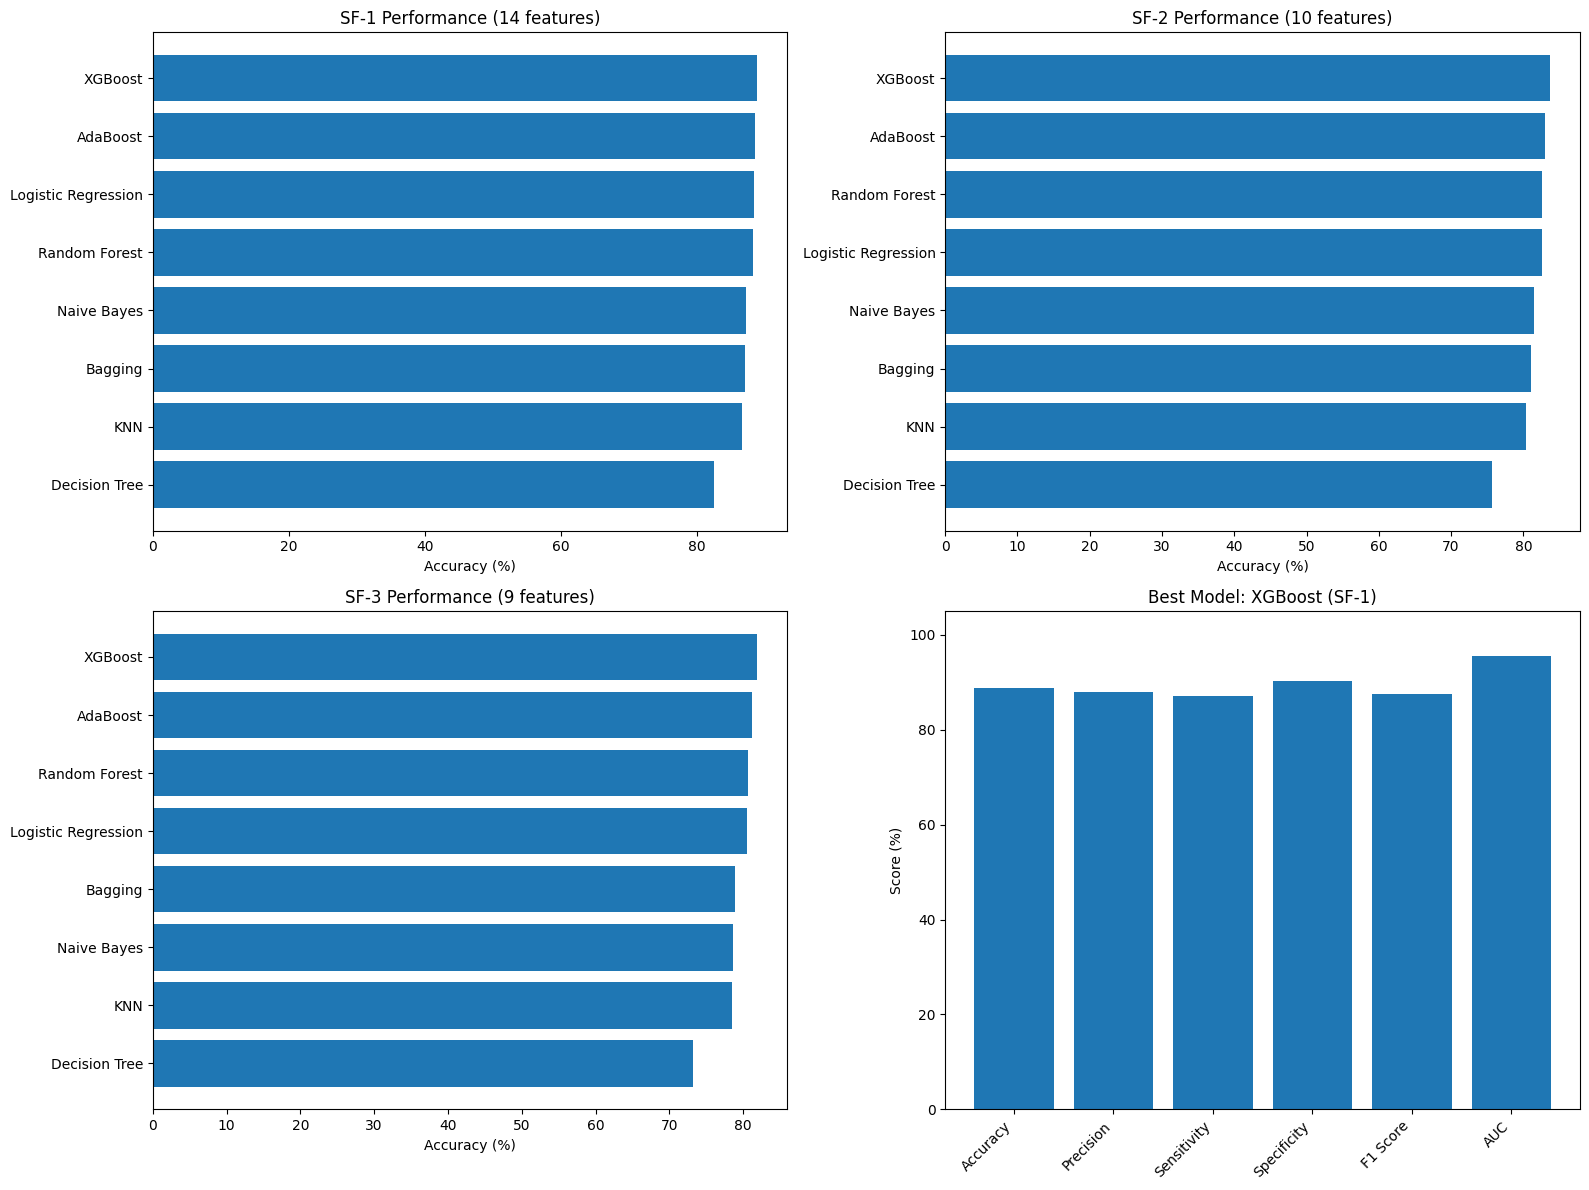

In [ ]:
# Visualise, vizualise, visualise!
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# SF-1 Results
axes[0, 0].barh(results_df_sf1['Model'], results_df_sf1['Accuracy'])
axes[0, 0].set_xlabel('Accuracy (%)')
axes[0, 0].set_title(f'SF-1 Performance ({len(SF_1)} features)')
axes[0, 0].invert_yaxis()

# SF-2 Results
axes[0, 1].barh(results_df_sf2['Model'], results_df_sf2['Accuracy'])
axes[0, 1].set_xlabel('Accuracy (%)')
axes[0, 1].set_title(f'SF-2 Performance ({len(SF_2)} features)')
axes[0, 1].invert_yaxis()

# SF-3 Results
axes[1, 0].barh(results_df_sf3['Model'], results_df_sf3['Accuracy'])
axes[1, 0].set_xlabel('Accuracy (%)')
axes[1, 0].set_title(f'SF-3 Performance ({len(SF_3)} features)')
axes[1, 0].invert_yaxis()

# best model metrics
metrics = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score', 'AUC']
values = [best_results.iloc[0][m] for m in metrics]
axes[1, 1].bar(metrics, values)
axes[1, 1].set_ylabel('Score (%)')
axes[1, 1].set_title(f'Best Model: {best_model_name} ({best_subset})')
axes[1, 1].set_ylim([0, 105])
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## SHAP Explainability Analysis

In [ ]:
# Preparation data for SHAP analysis
print(f"Applying SHAP analysis to {best_model_name} model")
print(f"Using feature subset: {best_subset}")

if best_subset == 'SF-1':
    X_shap = X_test
elif best_subset == 'SF-2':
    X_shap = X_test[SF_2]
else:
    X_shap = X_test[SF_3]

# creating SHAP explainer based on model type
if best_model_name in ['XGBoost', 'Random Forest', 'Decision Tree']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)
    # Handle different output formats
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Use positive class
else:
    # For other models, use KernelExplainer (slower but works for any model)
    if best_subset == 'SF-1':
        background = shap.sample(pd.DataFrame(X_train_smote, columns=X.columns), 100)
    elif best_subset == 'SF-2':
        background = shap.sample(pd.DataFrame(X_train_smote, columns=X.columns)[SF_2], 100)
    else:
        background = shap.sample(pd.DataFrame(X_train_smote, columns=X.columns)[SF_3], 100)
    
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

print(f"SHAP values computed successfully")
print(f"SHAP values shape: {shap_values.shape}")

Applying SHAP analysis to XGBoost model
Using feature subset: SF-1
SHAP values computed successfully
SHAP values shape: (157500, 14)


Generating SHAP summary plot (bar)...


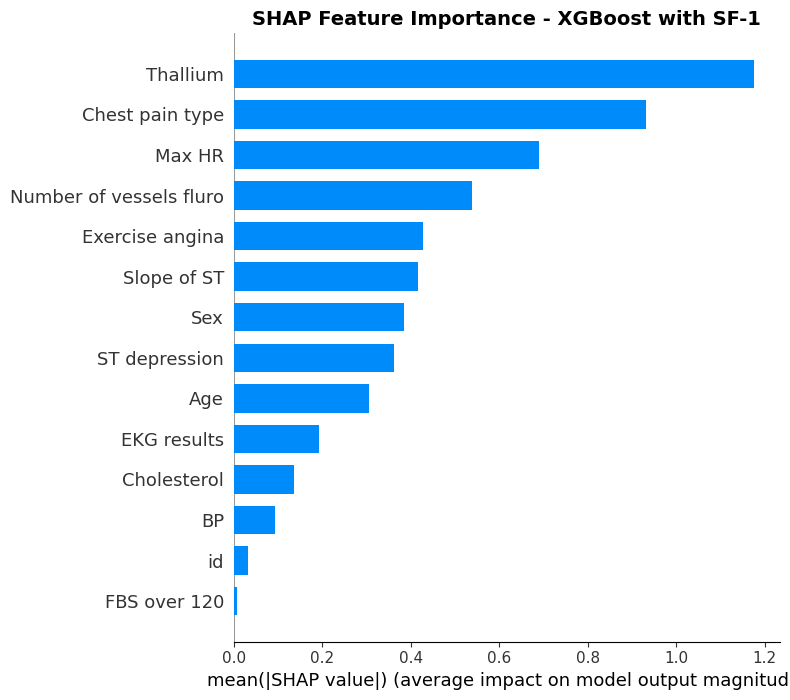

SHAP summary plot (bar) saved as 'shap_summary_bar.png'


In [21]:
# SHAP Summary Plot (Bar)
print("Generating SHAP summary plot (bar)...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title(f"SHAP Feature Importance - {best_model_name} with {best_subset}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP summary plot (bar) saved as 'shap_summary_bar.png'")

Generating detailed SHAP summary plot...


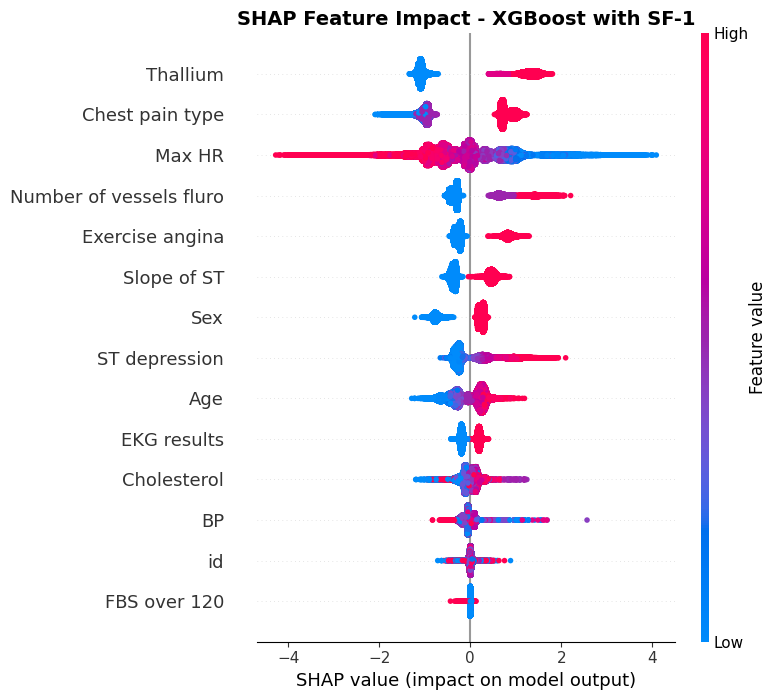

SHAP detailed summary plot saved as 'shap_summary_detailed.png'


In [22]:
# SHAP Detailed Summary Plot
print("Generating detailed SHAP summary plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title(f"SHAP Feature Impact - {best_model_name} with {best_subset}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_detailed.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP detailed summary plot saved as 'shap_summary_detailed.png'")


Feature Importance based on SHAP values:
                Feature  Mean_|SHAP|
               Thallium     1.176123
        Chest pain type     0.932848
                 Max HR     0.689592
Number of vessels fluro     0.538984
        Exercise angina     0.428145
            Slope of ST     0.416628
                    Sex     0.385446
          ST depression     0.361515
                    Age     0.306511
            EKG results     0.192011
            Cholesterol     0.137217
                     BP     0.093160
                     id     0.031220
           FBS over 120     0.007010


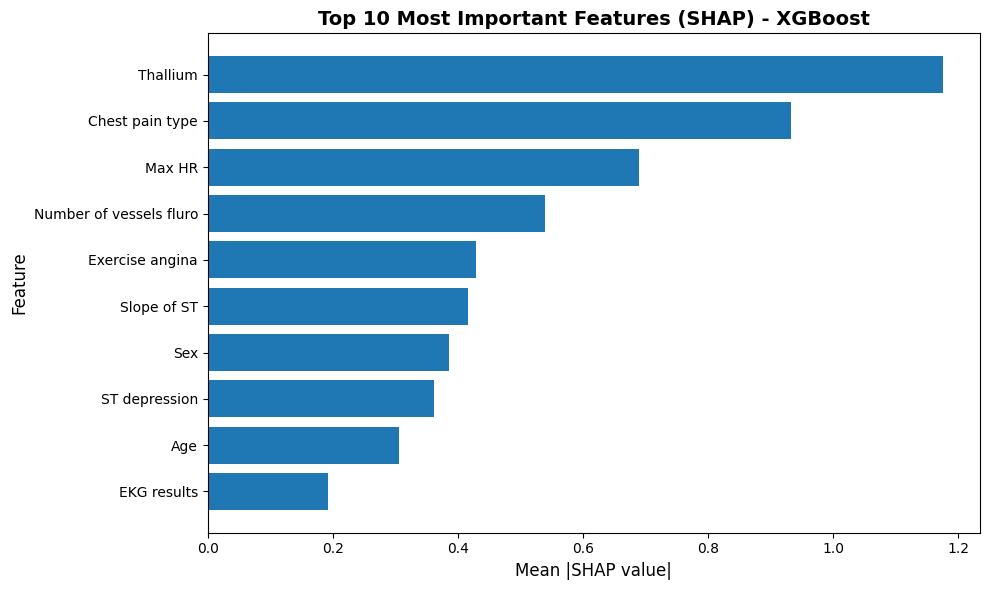


Top features plot saved as 'shap_top_features.png'


In [ ]:
# Calculating mean absolute SHAP values for feature importance
feature_importance_shap = pd.DataFrame({
    'Feature': best_features,
    'Mean_|SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

print("\nFeature Importance based on SHAP values:")
print("=" * 50)
print(feature_importance_shap.to_string(index=False))

# Visualize top features
plt.figure(figsize=(10, 6))
top_n = min(10, len(feature_importance_shap))
plt.barh(
    feature_importance_shap['Feature'][:top_n], 
    feature_importance_shap['Mean_|SHAP|'][:top_n]
)
plt.xlabel('Mean |SHAP value|', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Most Important Features (SHAP) - {best_model_name}', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('shap_top_features.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nTop features plot saved as 'shap_top_features.png'")

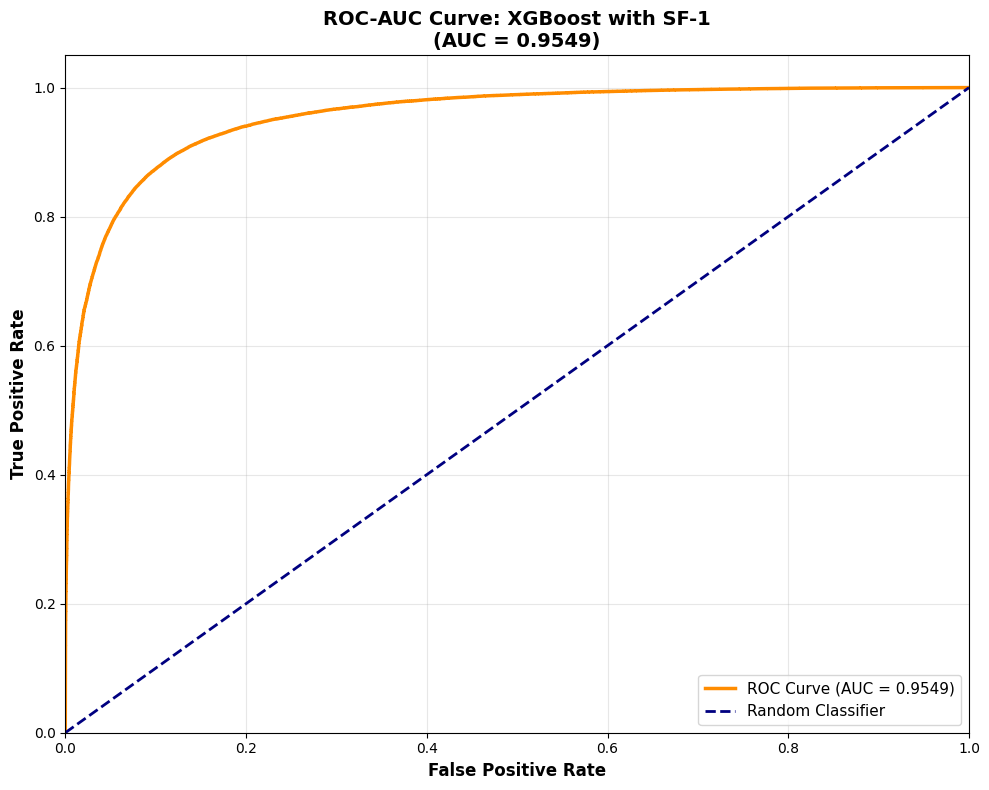

ROC-AUC Curve saved as: roc_auc_curve_XGBoost_SF-1.png

ROC-AUC Performance:
  AUC Score: 0.9549
  False Positive Rate (FPR) range: [0, 1]
  True Positive Rate (TPR) range: [0, 1]


In [ ]:
# Generate ROC-AUC Curve for the best model
from sklearn.metrics import roc_curve, auc

# Prepare test data based on best feature subset
if best_subset == 'SF-1':
    X_test_eval = X_test
elif best_subset == 'SF-2':
    X_test_eval = X_test[SF_2]
else:
    X_test_eval = X_test[SF_3]

# Get predictions and probabilities
y_pred_proba = best_model.predict_proba(X_test_eval)[:, 1] \
    if hasattr(best_model, 'predict_proba') else best_model.predict(X_test_eval)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC-AUC Curve: {best_model_name} with {best_subset}\n(AUC = {roc_auc:.4f})', 
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

# loading the ROC curve
roc_curve_filename = f'roc_auc_curve_{best_model_name.replace(" ", "_")}_{best_subset}.png'
plt.savefig(roc_curve_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Curve saved as: {roc_curve_filename}")
print(f"\nROC-AUC Performance:")
print(f"  AUC Score: {roc_auc:.4f}")
print(f"  False Positive Rate (FPR) range: [0, 1]")
print(f"  True Positive Rate (TPR) range: [0, 1]")

## Save Model and Generate Predictions

In [ ]:
# saving the best model(XGBooost for SF-1)
model_filename = f'best_heart_disease_model_{best_model_name.replace(" ", "_")}_{best_subset}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump({
        'model': best_model,
        'scaler': scaler,
        'features': best_features,
        'feature_subset': best_subset,
        'model_name': best_model_name,
        'performance': best_results.iloc[0].to_dict()
    }, f)

print(f"Best model saved as: {model_filename}")
print(f"\nModel Package Contains:")
print(f"  - Trained {best_model_name} model")
print(f"  - StandardScaler for feature normalization")
print(f"  - Feature list ({len(best_features)} features)")
print(f"  - Performance metrics")
print(f"\nModel Performance:")
print(f"  Algorithm: {best_model_name}")
print(f"  Feature Subset: {best_subset}")
print(f"  Accuracy: {best_results.iloc[0]['Accuracy']:.2f}%")

Best model saved as: best_heart_disease_model_XGBoost_SF-1.pkl

Model Package Contains:
  - Trained XGBoost model
  - StandardScaler for feature normalization
  - Feature list (14 features)
  - Performance metrics

Model Performance:
  Algorithm: XGBoost
  Feature Subset: SF-1
  Accuracy: 88.84%


In [ ]:
# predictions on test set
test_df = pd.read_csv("data/test.csv", encoding='utf-8')

print(f"Test dataset shape: {test_df.shape}")
test_ids = test_df['id'].values

# feature selection
if 'Heart Disease' in test_df.columns:
    test_df = test_df.drop('Heart Disease', axis=1)
if 'Heart_Disease' in test_df.columns:
    test_df = test_df.drop('Heart_Disease', axis=1)

# Standardization using StandardScaler
X_test_final = test_df[best_features]
X_test_final_scaled = scaler.transform(X_test_final)
X_test_final_scaled = pd.DataFrame(X_test_final_scaled, columns=best_features)

# Making predictions
predictions = best_model.predict(X_test_final_scaled)
predictions_proba = best_model.predict_proba(X_test_final_scaled)[:, 1] \
    if hasattr(best_model, 'predict_proba') else predictions

submission = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': predictions_proba
})

# saving to data/submission.csv
submission_filename = 'data/best_submission.csv'
submission.to_csv(submission_filename, index=False)

print(f"\nPredictions saved to: {submission_filename}")
print(f"\nSubmission file shape: {submission.shape}")
print(f"\nFirst 5 rows:")
print(submission.head())
print(f"\nProbability Statistics:")
print(submission['Heart Disease'].describe())

Test dataset shape: (270000, 14)

Predictions saved to: data/best_submission.csv

Submission file shape: (270000, 2)

First 5 rows:
       id  Heart Disease
0  630000       0.940490
1  630001       0.008842
2  630002       0.970220
3  630003       0.002527
4  630004       0.235194

Probability Statistics:
count    270000.000000
mean          0.452459
std           0.408681
min           0.000141
25%           0.040097
50%           0.315563
75%           0.929986
max           0.999948
Name: Heart Disease, dtype: float64


## Final Summary Report

In [26]:
# Final Summary Report
print("=" * 80)
print("HEART DISEASE PREDICTION - FINAL SUMMARY REPORT")
print("=" * 80)
print(f"\nResearch Paper: s41598-024-74656-2")
print(f"Title: A proposed technique for predicting heart disease using")
print(f"       machine learning algorithms and an explainable AI method")
print(f"Implementation Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\n{'=' * 80}")
print("METHODOLOGY IMPLEMENTED:")
print("=" * 80)
print("1. Data Preprocessing:")
print("   - StandardScaler normalization (mean=0, std=1)")
print("   - Missing value handling")
print("\n2. Feature Selection (Three Methods):")
print("   - ANOVA F-value (FSM1)")
print("   - Chi-square (FSM2)")
print("   - Mutual Information (FSM3)")
print(f"\n3. Feature Subsets:")
print(f"   - SF-1: {len(SF_1)} features (all)")
print(f"   - SF-2: {len(SF_2)} features (top 10)")
print(f"   - SF-3: {len(SF_3)} features (top 9)")
print("\n4. Data Balancing:")
print("   - SMOTE (Synthetic Minority Oversampling Technique)")
print("\n5. Train-Test Split:")
print("   - 75% training, 25% testing (stratified)")
print(f"\n6. Machine Learning Algorithms: {len(classifiers)}")
for i, name in enumerate(classifiers.keys(), 1):
    print(f"   {i}. {name}")
print("\n7. Explainability:")
print("   - SHAP (Shapley Additive Explanations)")

print(f"\n{'=' * 80}")
print("BEST MODEL PERFORMANCE:")
print("=" * 80)
print(f"Algorithm: {best_model_name}")
print(f"Feature Subset: {best_subset} ({len(best_features)} features)")
print(f"\nPerformance Metrics:")
for col in ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score', 'AUC']:
    print(f"  {col:20s}: {best_results.iloc[0][col]:6.2f}%")

print(f"\n{'=' * 80}")
print("SELECTED FEATURES:")
print("=" * 80)
for i, feat in enumerate(best_features, 1):
    print(f"  {i:2d}. {feat}")

print(f"\n{'=' * 80}")
print("OUTPUT FILES GENERATED:")
print("=" * 80)
print(f"1. Model File: {model_filename}")
print(f"2. Predictions: {submission_filename}")
print("3. Result CSVs:")
print("   - results_SF1.csv")
print("   - results_SF2.csv")
print("   - results_SF3.csv")
print("4. Visualizations:")
print("   - feature_selection_comparison.png")
print("   - smote_effect.png")
print("   - model_comparison.png")
print("   - shap_summary_bar.png")
print("   - shap_summary_detailed.png")
print("   - shap_top_features.png")

print(f"\n{'=' * 80}")
print("CONCLUSION:")
print("=" * 80)
print("✓ Successfully implemented the research paper methodology")
print(f"✓ The {best_model_name} model with {best_subset} achieved best performance")
print(f"✓ Model accuracy: {best_results.iloc[0]['Accuracy']:.2f}%")
print("✓ SHAP analysis provides model explainability")
print("✓ Model ready for deployment and early heart disease prediction")
print("=" * 80)

HEART DISEASE PREDICTION - FINAL SUMMARY REPORT

Research Paper: s41598-024-74656-2
Title: A proposed technique for predicting heart disease using
       machine learning algorithms and an explainable AI method
Implementation Date: 2026-03-01 02:39:50

METHODOLOGY IMPLEMENTED:
1. Data Preprocessing:
   - StandardScaler normalization (mean=0, std=1)
   - Missing value handling

2. Feature Selection (Three Methods):
   - ANOVA F-value (FSM1)
   - Chi-square (FSM2)
   - Mutual Information (FSM3)

3. Feature Subsets:
   - SF-1: 14 features (all)
   - SF-2: 10 features (top 10)
   - SF-3: 9 features (top 9)

4. Data Balancing:
   - SMOTE (Synthetic Minority Oversampling Technique)

5. Train-Test Split:
   - 75% training, 25% testing (stratified)

6. Machine Learning Algorithms: 8
   1. Naive Bayes
   2. XGBoost
   3. AdaBoost
   4. Bagging
   5. Decision Tree
   6. KNN
   7. Random Forest
   8. Logistic Regression

7. Explainability:
   - SHAP (Shapley Additive Explanations)

BEST MODEL PER

In [30]:
results_sf1 = pd.read_csv('results_SF1.csv')
results_sf2 = pd.read_csv('results_SF2.csv')
results_sf3 = pd.read_csv('results_SF3.csv')
results_sf3.head()

,Model,Accuracy,Precision,Sensitivity,Specificity,F1 Score,AUC
0,XGBoost,81.896508,79.213390,80.832141,82.761518,80.014579,89.800062
1,AdaBoost,81.120635,77.312452,81.933922,80.459678,79.556127,89.144919
2,Random Forest,80.609524,78.026605,78.996785,81.920195,78.508698,88.288403
3,Logistic Regression,80.523810,76.229444,82.187416,79.171798,79.096392,88.399927
4,Bagging,78.923175,77.999611,73.806523,83.081474,75.845158,86.008222


In [31]:
results_sf1.head()

,Model,Accuracy,Precision,Sensitivity,Specificity,F1 Score,AUC
0,XGBoost,88.836190,87.881818,87.111438,90.237895,87.494933,95.487590
1,AdaBoost,88.497143,86.933641,87.493804,89.312555,87.212823,95.268496
2,Logistic Regression,88.311746,86.616913,87.439990,89.020222,87.026505,95.101163
3,Random Forest,88.254603,86.905841,86.894764,89.359743,86.900302,94.861759
4,Naive Bayes,87.158730,85.161614,86.414683,87.763417,85.783573,93.879915


In [32]:
results_sf2.head()

,Model,Accuracy,Precision,Sensitivity,Specificity,F1 Score,AUC
0,XGBoost,83.649524,82.003795,81.392945,85.483444,81.697228,91.491470
1,AdaBoost,83.045079,79.913616,83.059777,83.033135,81.456328,90.982273
2,Random Forest,82.580317,80.702553,80.361973,84.383164,80.531903,90.231210
3,Logistic Regression,82.540317,79.398849,82.449407,82.614200,80.895379,90.446416
4,Naive Bayes,81.531429,78.476499,81.030405,81.938610,79.733006,88.866253
